# BrushCue Example: CRT Monitor Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/crt_monitor_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/crt-monitor-filter

In [ ]:
!pip install brushcue

creating texture TextureKey { size: (1739, 2160, 1), format: Rgba8Unorm, usage_style: Storage }
creating texture TextureKey { size: (1792, 2304, 1), format: Rgba16Float, usage_style: Storage }
creating texture TextureKey { size: (1739, 2160, 1), format: Rgba16Float, usage_style: Storage }


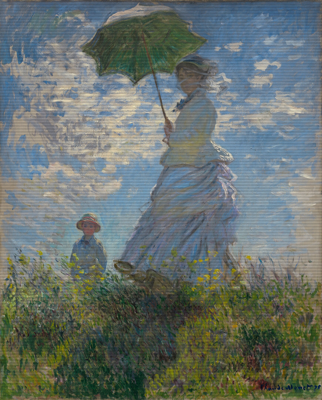

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
string_constant_2 = brushcue.string_constant("let c = sample(position); let safe_size = max(size, 0.001); let w = 0.5 + 0.5 * cos(3.14159265 * ((position.y / safe_size) + offset * 2.0)); let b = pow(w, sharpness); let f = (1.0 - intensity) + intensity * b; return vec4<f32>(c.r * f, c.g * f, c.b * f, c.a);")
string_constant_3 = brushcue.string_constant("\n")
string_constant_4 = brushcue.string_constant("size")
string_constant_5 = brushcue.string_constant("sharpness")
string_constant_6 = brushcue.string_constant("offset")
dictionary_create_7 = brushcue.dictionary_create()
string_constant_8 = brushcue.string_constant("intensity")
float_add_to_dictionary_9 = brushcue.float_add_to_dictionary(dictionary_create_7, string_constant_8, 0.15)
add_scanline_phase_10 = brushcue.float_add_to_dictionary(float_add_to_dictionary_9, string_constant_6, 0.0)
add_power_11 = brushcue.float_add_to_dictionary(add_scanline_phase_10, string_constant_5, 5.0)
float_add_to_dictionary_12 = brushcue.float_add_to_dictionary(add_power_11, string_constant_4, 8.0)
composition_spacial_effect_shader_13 = brushcue.composition_spacial_effect_shader(input_image_1, string_constant_2, string_constant_3, 0.0, float_add_to_dictionary_12)

ctx = brushcue.Context()
result = composition_spacial_effect_shader_13.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
